In [2]:
import os, sys, math, time, copy, pathlib, random, re, json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Metrics & helpers
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve,
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from collections import Counter

# Ensure we don't accidentally use torch
assert 'torch' not in sys.modules, "Torch should not be used."

USERNAME = "garima.mittal"
EPOCH_DIR = "epochs_{USERNAME}"
os.makedirs(EPOCH_DIR, exist_ok=True)

np.random.seed(42)
random.seed(42)

def stamp_username():
    plt.text(0.98, 0.02, USERNAME, ha='right', va='bottom',
             transform=plt.gca().transAxes, fontsize=9, color='gray', alpha=0.7)

def set_plot_style(title, xlabel, ylabel, legend=True):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if legend:
        plt.legend()
    stamp_username()


In [3]:
class Linear:
    def __init__(self, in_dim, out_dim):
        limit = 1.0 / np.sqrt(in_dim)
        self.W = np.random.uniform(-limit, limit, (in_dim, out_dim)).astype(np.float32)
        self.b = np.zeros((out_dim,), dtype=np.float32)

        self.x_cache = None
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        # Adam buffers
        self.mW = np.zeros_like(self.W); self.vW = np.zeros_like(self.W)
        self.mb = np.zeros_like(self.b); self.vb = np.zeros_like(self.b)

    def forward(self, x):
        self.x_cache = x
        return x @ self.W + self.b

    def backward(self, grad_out):
        x = self.x_cache
        self.dW += x.T @ grad_out
        self.db += grad_out.sum(axis=0)
        grad_in = grad_out @ self.W.T
        return grad_in

    def zero_grad(self):
        self.dW.fill(0.0); self.db.fill(0.0)

class ReLU:
    def __init__(self): self.mask = None
    def forward(self, x):
        self.mask = (x > 0).astype(np.float32)
        return x * self.mask
    def backward(self, g): return g * self.mask
    def zero_grad(self): pass

class Sigmoid:
    def __init__(self): self.out = None
    def forward(self, x):
        self.out = 1.0 / (1.0 + np.exp(-x))
        return self.out
    def backward(self, g): return g * self.out * (1.0 - self.out)
    def zero_grad(self): pass

class Tanh:
    def __init__(self): self.out = None
    def forward(self, x):
        self.out = np.tanh(x)
        return self.out
    def backward(self, g): return g * (1 - self.out**2)
    def zero_grad(self): pass

class Identity:
    def forward(self, x): return x
    def backward(self, g): return g
    def zero_grad(self): pass

class MSELoss:
    def __init__(self): self.y_pred=None; self.y_true=None
    def forward(self, y_pred, y_true):
        self.y_pred = y_pred; self.y_true = y_true
        return np.mean((y_pred - y_true)**2)
    def backward(self):
        N = self.y_true.shape[0]
        return (2.0/N) * (self.y_pred - self.y_true)

class Sequential:
    def __init__(self, layers): self.layers = layers
    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x
    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad
    def zero_grad(self):
        for layer in self.layers:
            layer.zero_grad()

class Adam:
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = params
        self.lr = lr; self.beta1=beta1; self.beta2=beta2; self.eps=eps
        self.t = 0
    def step(self):
        self.t += 1
        for p in self.params:
            # weights
            p.mW = self.beta1*p.mW + (1-self.beta1)*p.dW
            p.vW = self.beta2*p.vW + (1-self.beta2)*(p.dW**2)
            mW_hat = p.mW / (1 - self.beta1**self.t)
            vW_hat = p.vW / (1 - self.beta2**self.t)
            p.W -= self.lr * mW_hat / (np.sqrt(vW_hat) + self.eps)
            # biases
            p.mb = self.beta1*p.mb + (1-self.beta1)*p.db
            p.vb = self.beta2*p.vb + (1-self.beta2)*(p.db**2)
            mb_hat = p.mb / (1 - self.beta1**self.t)
            vb_hat = p.vb / (1 - self.beta2**self.t)
            p.b -= self.lr * mb_hat / (np.sqrt(vb_hat) + self.eps)
    def zero_grad(self):
        for p in self.params:
            p.zero_grad()

def build_mlp(dims, hidden_act='relu', out_act='sigmoid'):
    acts = {'relu': ReLU, 'sigmoid': Sigmoid, 'tanh': Tanh, 'identity': Identity}
    layers = []
    for i in range(len(dims)-1):
        layers.append(Linear(dims[i], dims[i+1]))
        if i < len(dims)-2:
            layers.append(acts[hidden_act]())
        else:
            layers.append(acts[out_act]())
    return Sequential(layers)

def batch_iterator(X, batch_size):
    N = X.shape[0]
    for i in range(0, N, batch_size):
        yield X[i:i+batch_size]


In [4]:
def load_mnist():
    X_train = X_test = y_train = y_test = None
    try:
        from tensorflow.keras.datasets import mnist
        (X_train, y_train), (X_test, y_test) = mnist.load_data()
        print("Loaded MNIST via keras.datasets.mnist")
    except Exception as e:
        print("Keras MNIST failed:", e)
        try:
            from sklearn.datasets import fetch_openml
            mnist_ = fetch_openml('mnist_784', version=1, as_frame=False)
            X = mnist_.data.reshape(-1,28,28).astype(np.uint8)
            y = mnist_.target.astype(np.int64)
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=10000, random_state=42, stratify=y)
            print("Loaded MNIST via OpenML")
        except Exception as e2:
            print("OpenML MNIST failed:", e2)
            # local fallback if user provides mnist.npz next to notebook
            local_npz = "mnist.npz"
            if os.path.exists(local_npz):
                with np.load(local_npz) as data:
                    X_train = data['x_train']; y_train = data['y_train']
                    X_test  = data['x_test'];  y_test  = data['y_test']
                print("Loaded MNIST from local mnist.npz")
            else:
                raise RuntimeError(
                    "MNIST not available. Install TF/Keras or scikit-learn OpenML, or put mnist.npz next to the notebook."
                )

    X_train = (X_train.astype(np.float32)/255.0).reshape(-1, 28*28)
    X_test  = (X_test.astype(np.float32)/255.0).reshape(-1, 28*28)
    return X_train, y_train, X_test, y_test

def recon_grid(images, rows=2, cols=10, h=28, w=28):
    grid = np.zeros((rows*h, cols*w))
    for r in range(rows):
        for c in range(cols):
            i = r*cols + c
            if i < images.shape[0]:
                grid[r*h:(r+1)*h, c*w:(c+1)*w] = images[i].reshape(h,w)
    return grid

def save_epoch_grid(epoch, model, X_fixed, prefix="mnist"):
    with np.errstate(all='ignore'):
        preds = model.forward(X_fixed)
    grid = recon_grid(np.vstack([X_fixed, preds]))
    plt.figure(figsize=(12,3))
    plt.imshow(grid, cmap='gray', vmin=0, vmax=1)
    set_plot_style(f"{prefix} Epoch {epoch} — originals (top) / recon (bottom)",
                   "columns", "rows", legend=False)
    out_path = os.path.join(EPOCH_DIR, f"{prefix}_epoch_{epoch:03d}_{USERNAME}.png")
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print("Saved:", out_path)

def train_autoencoder(ae, X, X_fixed, y_test=None, max_epochs=15, batch_size=256,
                      patience=5, rel_drop=0.01, prefix="mnist"):
    loss_fn = MSELoss()
    opt = Adam(params=[ly for ly in ae.layers if isinstance(ly, Linear)], lr=1e-3)

    history = []
    best_loss = float('inf'); best_params = None
    start = time.time()
    for epoch in range(1, max_epochs+1):
        X = shuffle(X, random_state=epoch)
        epoch_loss = 0.0; nsum = 0
        for xb in batch_iterator(X, batch_size):
            recon = ae.forward(xb)
            loss = loss_fn.forward(recon, xb)
            grad = loss_fn.backward()
            ae.backward(grad)
            opt.step(); opt.zero_grad()
            epoch_loss += loss * xb.shape[0]; nsum += xb.shape[0]
        epoch_loss /= nsum
        history.append(epoch_loss)

        save_epoch_grid(epoch, ae, X_fixed, prefix=prefix)
        print(f"Epoch {epoch:02d} | {prefix} MSE: {epoch_loss:.6f}")

        if epoch > patience and history[-1] >= (1.0 - rel_drop) * history[-(patience+1)]:
            print(f"Early stopping: < {rel_drop*100:.1f}% improvement over last {patience} epochs.")
            break

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            best_params = [
                (copy.deepcopy(ly.W) if hasattr(ly,'W') else None,
                 copy.deepcopy(ly.b) if hasattr(ly,'b') else None)
                for ly in ae.layers
            ]

    if best_params is not None:
        for ly, (W, b) in zip(ae.layers, best_params):
            if W is not None: ly.W = W
            if b is not None: ly.b = b

    dur = time.time() - start
    return history, dur


Keras MNIST failed: No module named 'tensorflow.python'
Loaded MNIST via OpenML
MNIST shapes: (60000, 784) (10000, 784)


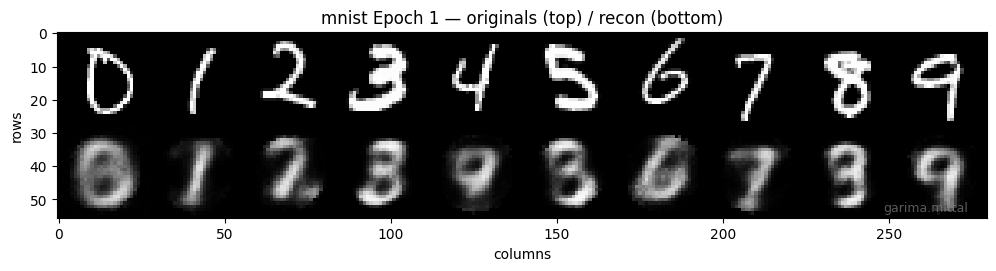

Saved: epochs_{USERNAME}\mnist_epoch_001_garima.mittal.png
Epoch 01 | mnist MSE: 0.068834


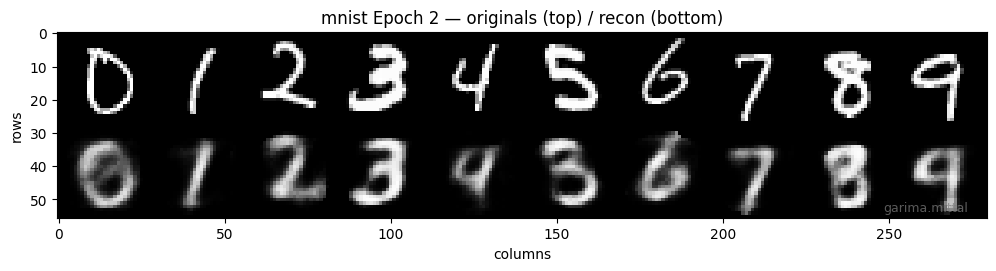

Saved: epochs_{USERNAME}\mnist_epoch_002_garima.mittal.png
Epoch 02 | mnist MSE: 0.033120


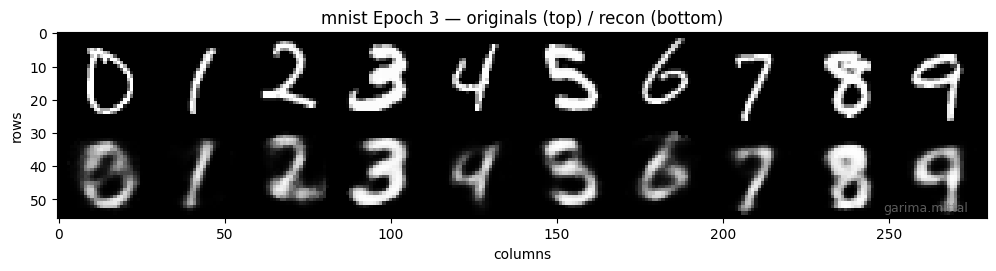

Saved: epochs_{USERNAME}\mnist_epoch_003_garima.mittal.png
Epoch 03 | mnist MSE: 0.024812


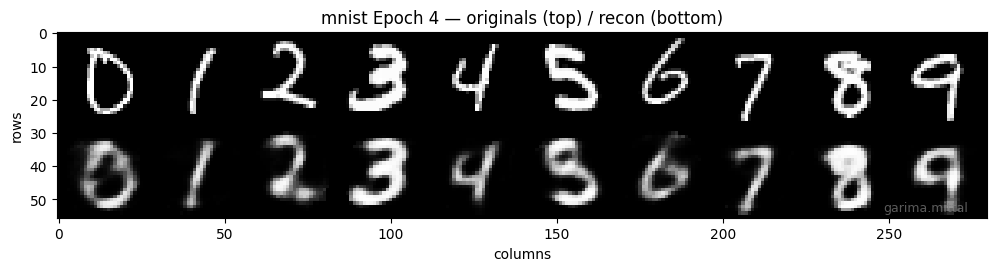

Saved: epochs_{USERNAME}\mnist_epoch_004_garima.mittal.png
Epoch 04 | mnist MSE: 0.020747


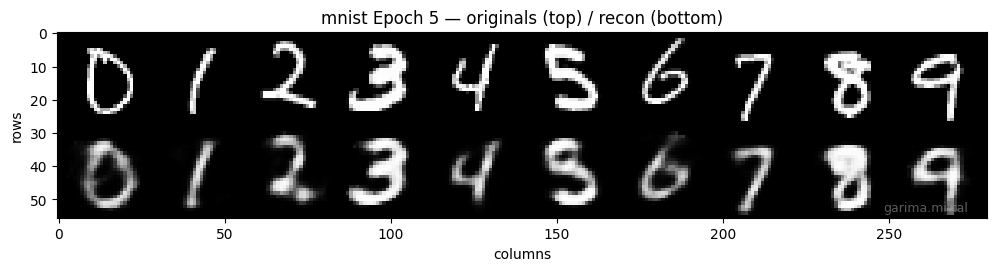

Saved: epochs_{USERNAME}\mnist_epoch_005_garima.mittal.png
Epoch 05 | mnist MSE: 0.018528


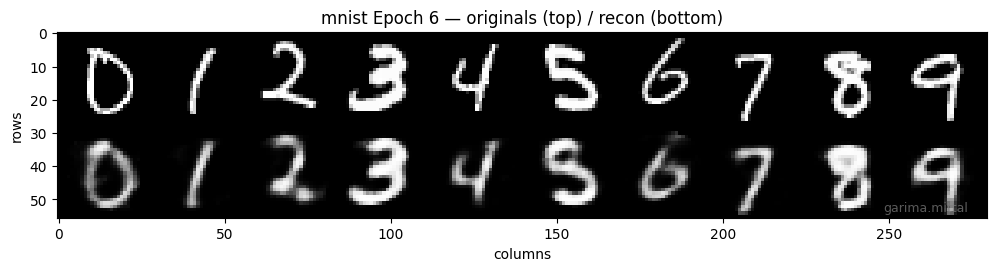

Saved: epochs_{USERNAME}\mnist_epoch_006_garima.mittal.png
Epoch 06 | mnist MSE: 0.017009


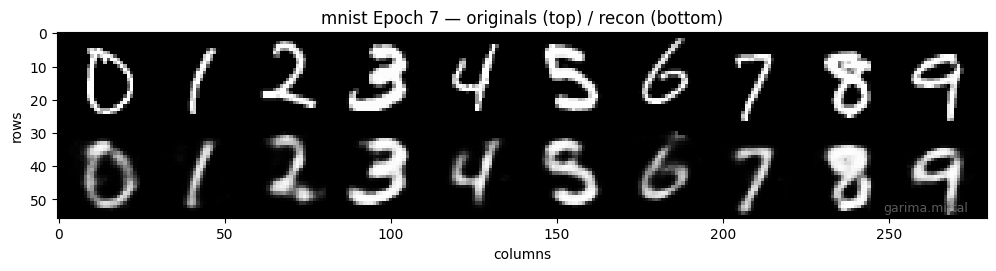

Saved: epochs_{USERNAME}\mnist_epoch_007_garima.mittal.png
Epoch 07 | mnist MSE: 0.015839


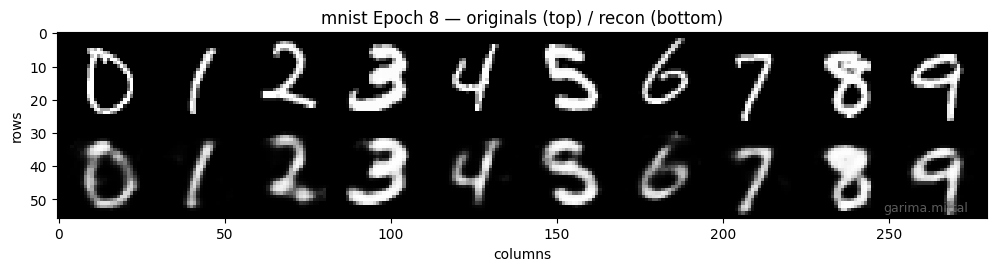

Saved: epochs_{USERNAME}\mnist_epoch_008_garima.mittal.png
Epoch 08 | mnist MSE: 0.014786


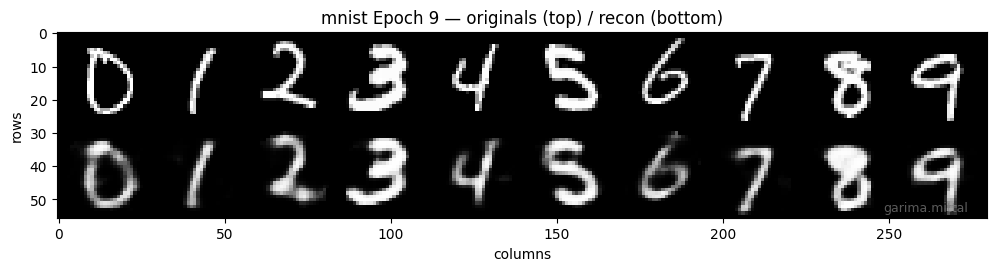

Saved: epochs_{USERNAME}\mnist_epoch_009_garima.mittal.png
Epoch 09 | mnist MSE: 0.014025


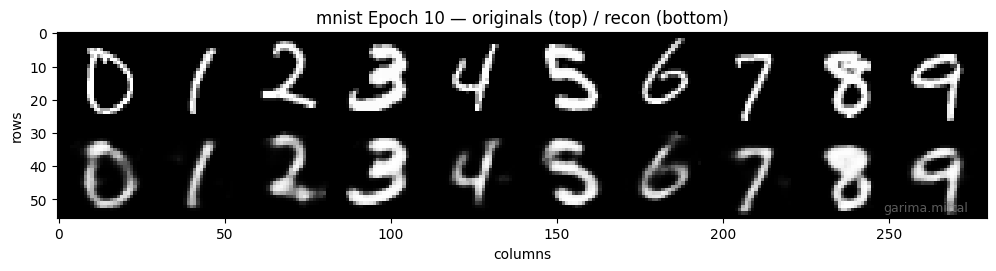

Saved: epochs_{USERNAME}\mnist_epoch_010_garima.mittal.png
Epoch 10 | mnist MSE: 0.013440


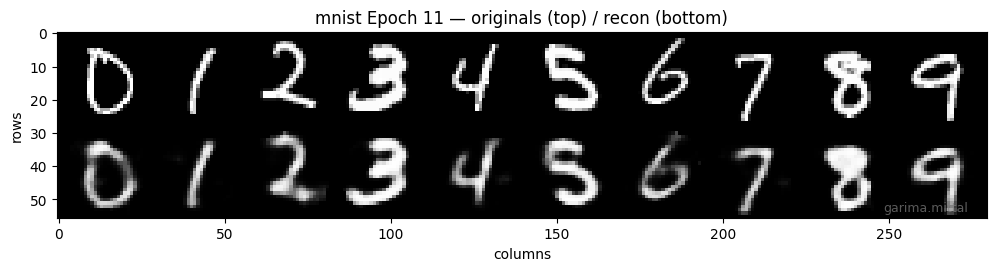

Saved: epochs_{USERNAME}\mnist_epoch_011_garima.mittal.png
Epoch 11 | mnist MSE: 0.012911


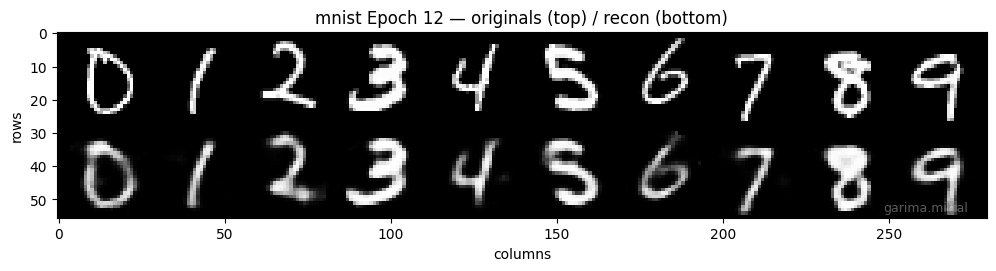

Saved: epochs_{USERNAME}\mnist_epoch_012_garima.mittal.png
Epoch 12 | mnist MSE: 0.012465


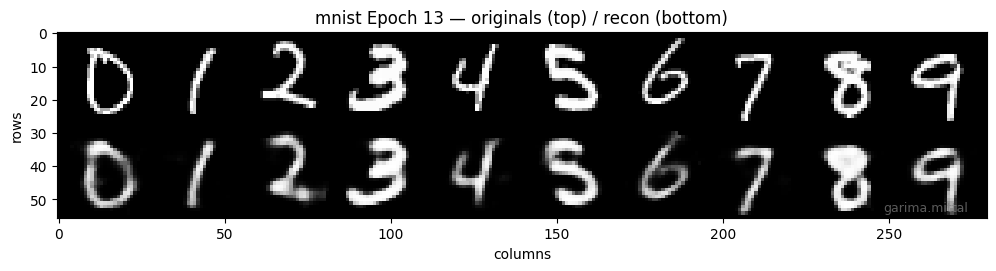

Saved: epochs_{USERNAME}\mnist_epoch_013_garima.mittal.png
Epoch 13 | mnist MSE: 0.012097


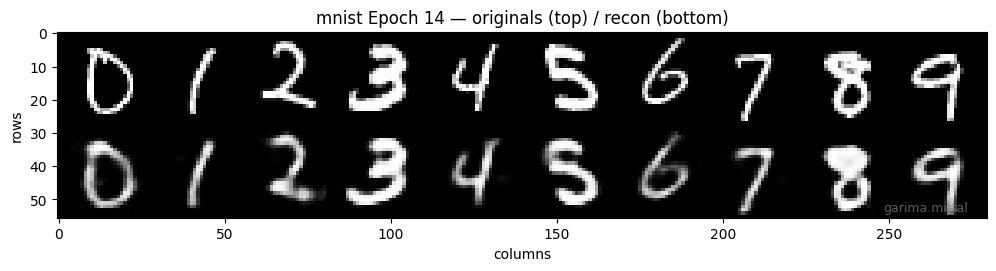

Saved: epochs_{USERNAME}\mnist_epoch_014_garima.mittal.png
Epoch 14 | mnist MSE: 0.011801


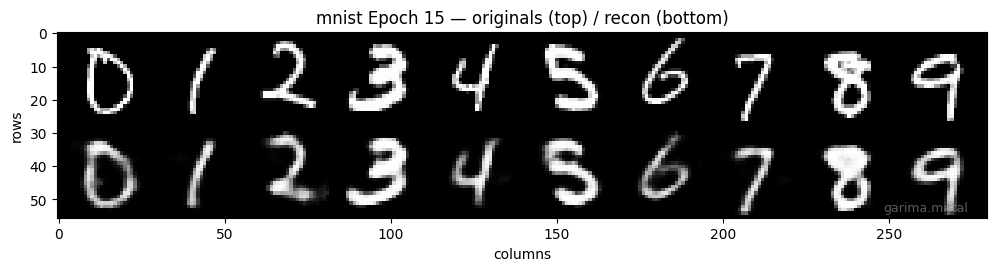

Saved: epochs_{USERNAME}\mnist_epoch_015_garima.mittal.png
Epoch 15 | mnist MSE: 0.011564


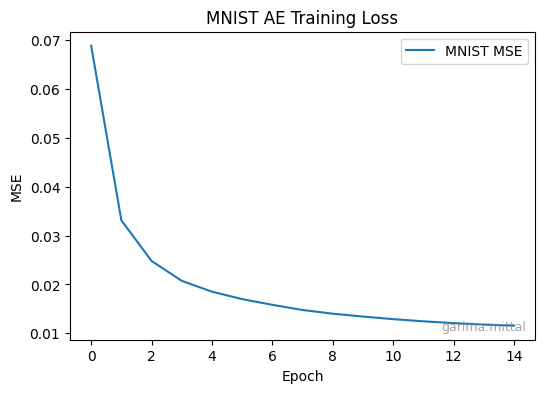

Training time (s): 31.29


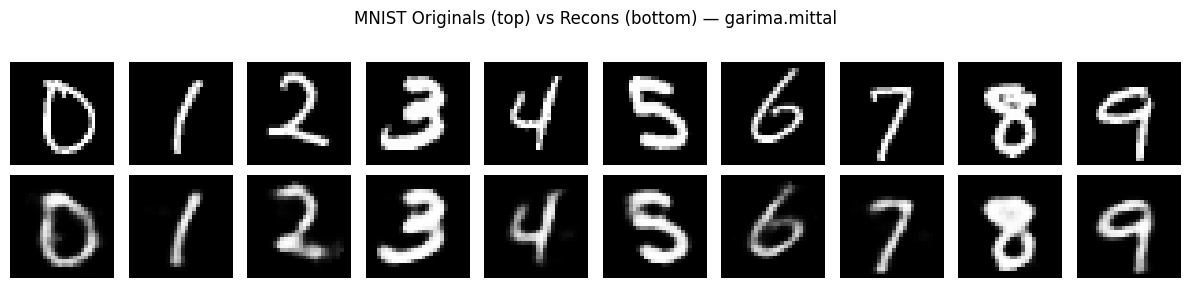

In [5]:
# Load MNIST
X_train_m, y_train_m, X_test_m, y_test_m = load_mnist()
print("MNIST shapes:", X_train_m.shape, X_test_m.shape)

# Build Autoencoder
input_dim = 28*28
latent_dim = 32
hidden = 128
ae_mnist = build_mlp([input_dim, hidden, latent_dim, hidden, input_dim],
                     hidden_act='relu', out_act='sigmoid')

# Pick one index per digit 0..9 to visualize each epoch
fixed_idx = []
for d in range(10):
    indices = np.where(y_test_m == d)[0]
    fixed_idx.append(indices[0] if len(indices) else d)  # fallback
fixed_idx = np.array(fixed_idx, dtype=int)
X_fixed = X_test_m[fixed_idx]

# Train
hist_mnist, dur_mnist = train_autoencoder(
    ae_mnist, X_train_m, X_fixed, y_test=y_test_m,
    max_epochs=15, batch_size=256, patience=5, rel_drop=0.01, prefix="mnist"
)

# Training curve
plt.figure(figsize=(6,4))
plt.plot(hist_mnist, label='MNIST MSE')
set_plot_style("MNIST AE Training Loss", "Epoch", "MSE")
plt.show()
print(f"Training time (s): {dur_mnist:.2f}")

# Final original vs reconstruction (0..9)
orig = X_fixed
recon = ae_mnist.forward(orig)
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(10):
    axes[0,i].imshow(orig[i].reshape(28,28), cmap='gray', vmin=0, vmax=1); axes[0,i].axis('off')
    axes[1,i].imshow(recon[i].reshape(28,28), cmap='gray', vmin=0, vmax=1); axes[1,i].axis('off')
fig.suptitle(f"MNIST Originals (top) vs Recons (bottom) — {USERNAME}")
plt.tight_layout(); plt.show()


Using LFW root: LFW_Dataset/LFW_Dataset
LFW loaded: (13233, 2914)
People (count): 5749
Top-10 label counts: [(np.str_('George_W_Bush'), 530), (np.str_('Colin_Powell'), 236), (np.str_('Tony_Blair'), 144), (np.str_('Donald_Rumsfeld'), 121), (np.str_('Gerhard_Schroeder'), 109), (np.str_('Ariel_Sharon'), 77), (np.str_('Hugo_Chavez'), 71), (np.str_('Junichiro_Koizumi'), 60), (np.str_('Jean_Chretien'), 55), (np.str_('John_Ashcroft'), 53)]
Using normal identity folder: George_W_Bush
Normals train/test: (424, 2914) (106, 2914) | Eval set: (12809, 2914)
[latent=8] Epoch 01 | Loss: 0.078811
[latent=8] Epoch 02 | Loss: 0.058106
[latent=8] Epoch 03 | Loss: 0.052131
[latent=8] Epoch 04 | Loss: 0.051306
[latent=8] Epoch 05 | Loss: 0.050468
[latent=8] Epoch 06 | Loss: 0.050113
[latent=8] Epoch 07 | Loss: 0.049473
[latent=8] Epoch 08 | Loss: 0.048973
[latent=8] Epoch 09 | Loss: 0.048852
[latent=8] Epoch 10 | Loss: 0.048571
[latent=8] Epoch 11 | Loss: 0.047856
[latent=8] Epoch 12 | Loss: 0.047373
[late

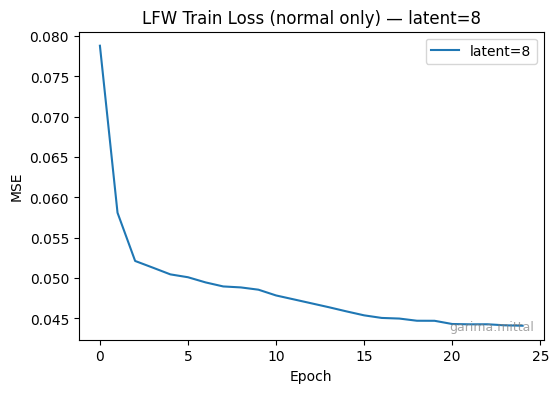

AUC (ROC): 0.6336
Best-F1 threshold: 0.050146
Precision: 0.9955 | Recall: 0.5019 | F1: 0.6674


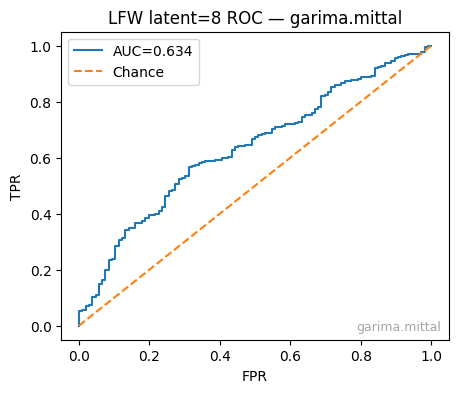

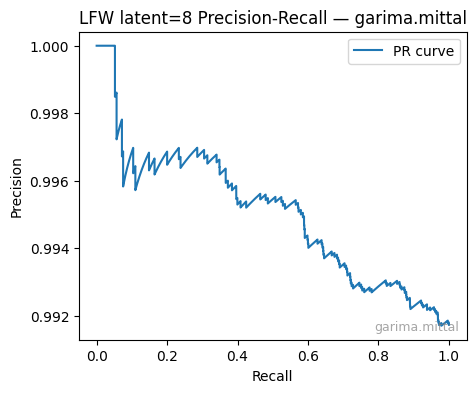

[latent=32] Epoch 01 | Loss: 0.078914
[latent=32] Epoch 02 | Loss: 0.057184
[latent=32] Epoch 03 | Loss: 0.050453
[latent=32] Epoch 04 | Loss: 0.047886
[latent=32] Epoch 05 | Loss: 0.045365
[latent=32] Epoch 06 | Loss: 0.043182
[latent=32] Epoch 07 | Loss: 0.041878
[latent=32] Epoch 08 | Loss: 0.040833
[latent=32] Epoch 09 | Loss: 0.039303
[latent=32] Epoch 10 | Loss: 0.037933
[latent=32] Epoch 11 | Loss: 0.036649
[latent=32] Epoch 12 | Loss: 0.035608
[latent=32] Epoch 13 | Loss: 0.034971
[latent=32] Epoch 14 | Loss: 0.034165
[latent=32] Epoch 15 | Loss: 0.033458
[latent=32] Epoch 16 | Loss: 0.032557
[latent=32] Epoch 17 | Loss: 0.031461
[latent=32] Epoch 18 | Loss: 0.030753
[latent=32] Epoch 19 | Loss: 0.029996
[latent=32] Epoch 20 | Loss: 0.029635
[latent=32] Epoch 21 | Loss: 0.029439
[latent=32] Epoch 22 | Loss: 0.029055
[latent=32] Epoch 23 | Loss: 0.028581
[latent=32] Epoch 24 | Loss: 0.027938
[latent=32] Epoch 25 | Loss: 0.027692


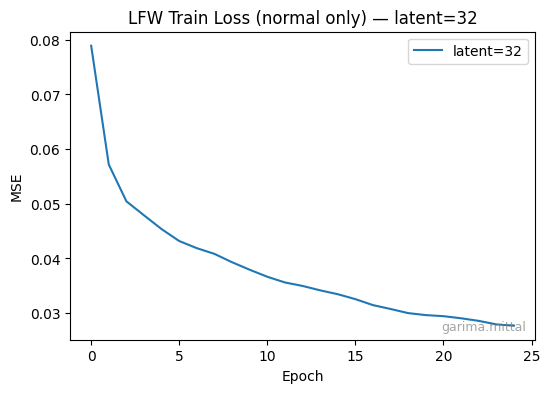

AUC (ROC): 0.6401
Best-F1 threshold: 0.034651
Precision: 0.9953 | Recall: 0.5018 | F1: 0.6673


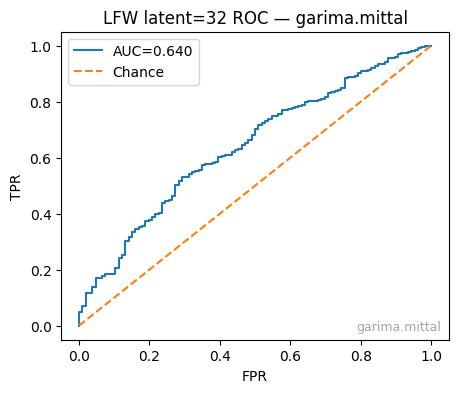

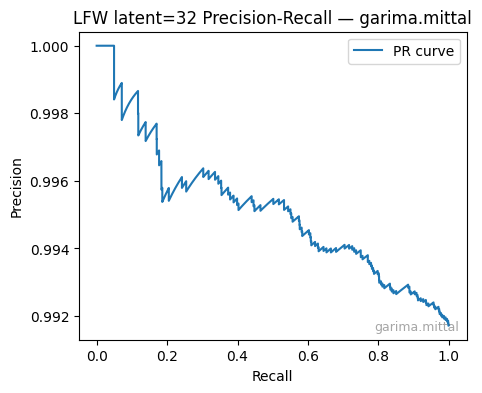

[latent=64] Epoch 01 | Loss: 0.077761
[latent=64] Epoch 02 | Loss: 0.056394
[latent=64] Epoch 03 | Loss: 0.049226
[latent=64] Epoch 04 | Loss: 0.046003
[latent=64] Epoch 05 | Loss: 0.043559
[latent=64] Epoch 06 | Loss: 0.042328
[latent=64] Epoch 07 | Loss: 0.041230
[latent=64] Epoch 08 | Loss: 0.040003
[latent=64] Epoch 09 | Loss: 0.038010
[latent=64] Epoch 10 | Loss: 0.036315
[latent=64] Epoch 11 | Loss: 0.034903
[latent=64] Epoch 12 | Loss: 0.034237
[latent=64] Epoch 13 | Loss: 0.033710
[latent=64] Epoch 14 | Loss: 0.033000
[latent=64] Epoch 15 | Loss: 0.031993
[latent=64] Epoch 16 | Loss: 0.031225
[latent=64] Epoch 17 | Loss: 0.030410
[latent=64] Epoch 18 | Loss: 0.029703
[latent=64] Epoch 19 | Loss: 0.029000
[latent=64] Epoch 20 | Loss: 0.028373
[latent=64] Epoch 21 | Loss: 0.027805
[latent=64] Epoch 22 | Loss: 0.027042
[latent=64] Epoch 23 | Loss: 0.026247
[latent=64] Epoch 24 | Loss: 0.025395
[latent=64] Epoch 25 | Loss: 0.024903


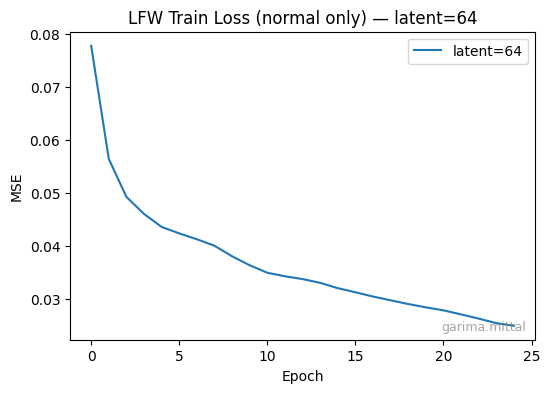

AUC (ROC): 0.6454
Best-F1 threshold: 0.031887
Precision: 0.9952 | Recall: 0.5018 | F1: 0.6672


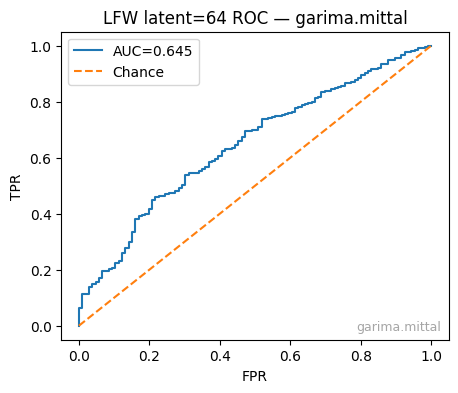

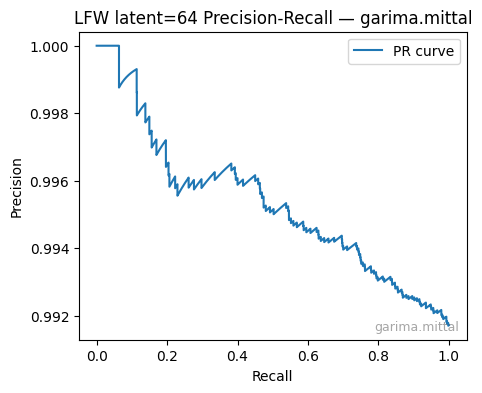

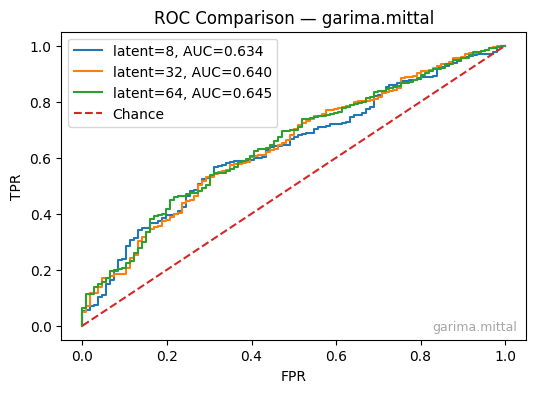

Best latent dim by AUC: 64 (AUC=0.6454)
Final Metrics (best): Precision=0.9952, Recall=0.5018, F1=0.6672, AUC=0.6454


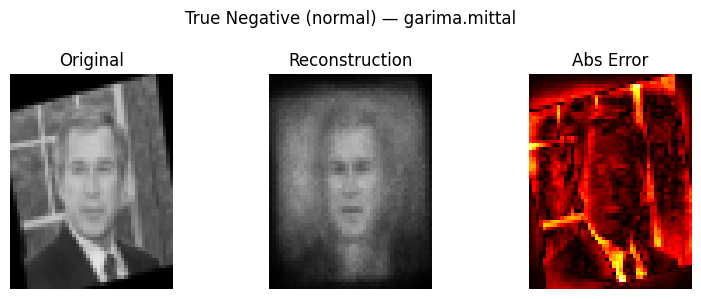

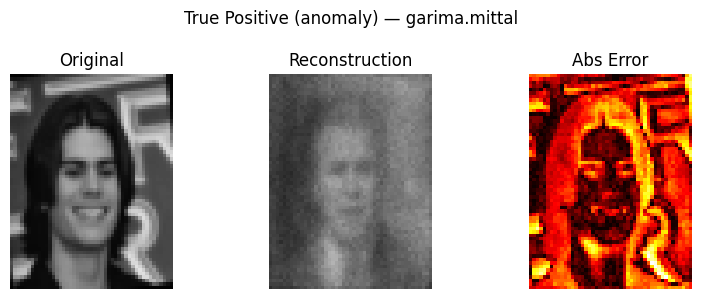

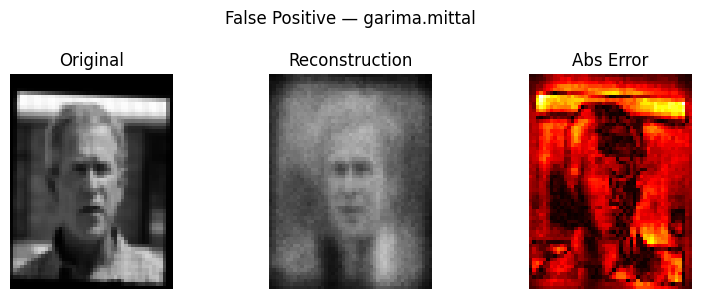

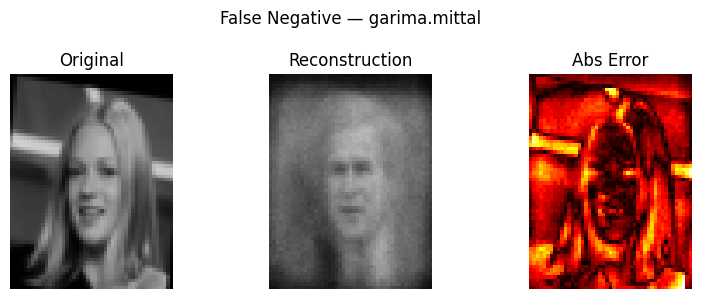

In [8]:
# --- LFW LOCAL LOADER ---
def find_lfw_root():
    candidates = [
        "LFW_Dataset/LFW_Dataset"
    ]
    for p in candidates:
        if os.path.isdir(p):
            return p
    # fallback: try any subdir containing many subfolders
    for p in os.listdir("."):
        if os.path.isdir(p):
            subdirs = [d for d in os.listdir(p) if os.path.isdir(os.path.join(p,d))]
            if len(subdirs) > 3:  # heuristic
                return p
    raise FileNotFoundError("Could not find LFW directory. Please set `LFW_ROOT` manually.")

LFW_ROOT = find_lfw_root()
print("Using LFW root:", LFW_ROOT)

def load_lfw_local(root, target_size=(62, 47), as_gray=True, limit_per_person=None):
    """
    Expects directory structure:
      root/
        Person_A/
           img1.jpg, img2.jpg, ...
        Person_B/
           ...
    Returns: X (N, H*W), labels (list of folder names), images (N, H, W)
    """
    H, W = target_size
    X_list, y_list, imgs_list = [], [], []
    persons = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])

    for person in persons:
        pdir = os.path.join(root, person)
        files = sorted([f for f in os.listdir(pdir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
        if limit_per_person:
            files = files[:limit_per_person]
        for fname in files:
            path = os.path.join(pdir, fname)
            try:
                img = Image.open(path)
                if as_gray:
                    img = img.convert("L")
                img = img.resize((W, H), Image.BILINEAR)
                arr = np.asarray(img).astype(np.float32)
                if not as_gray and arr.ndim == 3:
                    # convert RGB to gray if needed
                    arr = 0.299*arr[...,0] + 0.587*arr[...,1] + 0.114*arr[...,2]
                arr = arr / 255.0
                imgs_list.append(arr)
                X_list.append(arr.reshape(-1))
                y_list.append(person)
            except Exception as e:
                print("Failed to load:", path, "|", e)
    X = np.stack(X_list, axis=0)
    labels = np.array(y_list)
    images = np.stack(imgs_list, axis=0)
    return X, labels, images, (H, W)

X_lfw, labels_lfw, imgs_lfw, (h, w) = load_lfw_local(LFW_ROOT, target_size=(62,47), as_gray=True)
print("LFW loaded:", X_lfw.shape)
print("People (count):", len(set(labels_lfw)))
print("Top-10 label counts:", Counter(labels_lfw).most_common(10))

# Identify George W. Bush folder name (case-insensitive variants)
def match_gwb_name(name):
    name_clean = name.lower().replace(" ", "_")
    return bool(re.search(r"george[_\s]?w[._\s]?[_\s]?bush", name_clean))

unique_people = sorted(set(labels_lfw))
gwb_folders = [p for p in unique_people if match_gwb_name(p)]
if not gwb_folders:
    raise RuntimeError("Could not find George W. Bush folder. Please ensure a folder like 'George_W_Bush' exists.")
GWB = gwb_folders[0]
print("Using normal identity folder:", GWB)

is_normal = (labels_lfw == GWB)
X_normal = X_lfw[is_normal]
X_anom   = X_lfw[~is_normal]

# train/test split for normals
Xn_train, Xn_test = train_test_split(X_normal, test_size=0.2, random_state=42)
X_eval = np.vstack([Xn_test, X_anom])
y_eval = np.hstack([np.zeros(len(Xn_test), dtype=int), np.ones(len(X_anom), dtype=int)])  # 0 normal, 1 anomaly
print("Normals train/test:", Xn_train.shape, Xn_test.shape, "| Eval set:", X_eval.shape)

# --- TRAIN AE ON NORMALS ---
def train_ae_on_normals(input_dim, latent_dim=32, hidden=256, max_epochs=25,
                        batch_size=64, lr=1e-3, patience=6, rel_drop=0.01):
    ae = build_mlp([input_dim, hidden, latent_dim, hidden, input_dim],
                   hidden_act='relu', out_act='sigmoid')
    loss_fn = MSELoss()
    opt = Adam(params=[ly for ly in ae.layers if isinstance(ly, Linear)], lr=lr)

    history = []; best_loss=float('inf'); best_params=None
    for ep in range(1, max_epochs+1):
        Xtr = shuffle(Xn_train, random_state=ep)
        ep_loss = 0.0; nsum=0
        for xb in batch_iterator(Xtr, batch_size):
            pred = ae.forward(xb)
            loss = loss_fn.forward(pred, xb)
            grad = loss_fn.backward()
            ae.backward(grad)
            opt.step(); opt.zero_grad()
            ep_loss += loss * xb.shape[0]; nsum += xb.shape[0]
        ep_loss /= nsum
        history.append(ep_loss)
        print(f"[latent={latent_dim}] Epoch {ep:02d} | Loss: {ep_loss:.6f}")

        if ep > patience and history[-1] >= (1.0 - rel_drop) * history[-(patience+1)]:
            print(f"Early stopping: < {rel_drop*100:.1f}% improvement over {patience} epochs.")
            break

        if ep_loss < best_loss:
            best_loss = ep_loss
            best_params = [
                (copy.deepcopy(ly.W) if hasattr(ly,'W') else None,
                 copy.deepcopy(ly.b) if hasattr(ly,'b') else None)
                for ly in ae.layers
            ]

    if best_params is not None:
        for ly, (W,b) in zip(ae.layers, best_params):
            if W is not None: ly.W = W
            if b is not None: ly.b = b
    return ae, history

def evaluate_anomaly(ae_model, X_eval, y_eval, title_prefix="LFW"):
    with np.errstate(all='ignore'):
        X_recon = ae_model.forward(X_eval)
    errs = np.mean((X_eval - X_recon)**2, axis=1)

    # ROC / AUC
    fpr, tpr, thr = roc_curve(y_eval, errs)
    auc_roc = auc(fpr, tpr)

    # PR
    prec, rec, thr_pr = precision_recall_curve(y_eval, errs)
    f1s = 2 * (prec * rec) / (prec + rec + 1e-12)
    best_idx = np.nanargmax(f1s)
    best_f1 = f1s[best_idx]
    thr_best = thr_pr[best_idx-1] if best_idx>0 and best_idx-1 < len(thr_pr) else np.median(errs)

    y_pred = (errs >= thr_best).astype(int)
    P = precision_score(y_eval, y_pred, zero_division=0)
    R = recall_score(y_eval, y_pred, zero_division=0)
    F1 = f1_score(y_eval, y_pred, zero_division=0)

    print(f"AUC (ROC): {auc_roc:.4f}")
    print(f"Best-F1 threshold: {thr_best:.6f}")
    print(f"Precision: {P:.4f} | Recall: {R:.4f} | F1: {F1:.4f}")

    # ROC plot
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC={auc_roc:.3f}")
    plt.plot([0,1],[0,1],'--', label="Chance")
    set_plot_style(f"{title_prefix} ROC — {USERNAME}", "FPR", "TPR")
    plt.show()

    # PR plot
    plt.figure(figsize=(5,4))
    plt.plot(rec, prec, label="PR curve")
    set_plot_style(f"{title_prefix} Precision-Recall — {USERNAME}", "Recall", "Precision")
    plt.show()

    return dict(
        errs=errs, y_pred=y_pred, y_true=y_eval,
        auc=auc_roc, f1=F1, precision=P, recall=R,
        thr=thr_best, X_recon=X_recon
    )

# Train/eval for multiple latent dimensions
latent_list = [8, 32, 64]
results = {}
for ld in latent_list:
    ae_ld, hist_ld = train_ae_on_normals(input_dim=X_lfw.shape[1], latent_dim=ld, hidden=256,
                                         max_epochs=25, batch_size=64, lr=1e-3,
                                         patience=6, rel_drop=0.01)
    # plot train loss
    plt.figure(figsize=(6,4))
    plt.plot(hist_ld, label=f"latent={ld}")
    set_plot_style(f"LFW Train Loss (normal only) — latent={ld}", "Epoch", "MSE")
    plt.show()

    res = evaluate_anomaly(ae_ld, X_eval, y_eval, title_prefix=f"LFW latent={ld}")
    results[ld] = (ae_ld, res)

# Compare ROC curves across latent dims
plt.figure(figsize=(6,4))
for ld, (model, res) in results.items():
    fpr, tpr, _ = roc_curve(res['y_true'], res['errs'])
    auc_roc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"latent={ld}, AUC={auc_roc:.3f}")
plt.plot([0,1],[0,1],'--', label="Chance")
set_plot_style(f"ROC Comparison — {USERNAME}", "FPR", "TPR")
plt.show()

# Choose best by AUC and print final summary
best_ld = max(results.keys(), key=lambda k: results[k][1]['auc'])
best_model, best_res = results[best_ld]
print(f"Best latent dim by AUC: {best_ld} (AUC={best_res['auc']:.4f})")
print(f"Final Metrics (best): Precision={best_res['precision']:.4f}, "
      f"Recall={best_res['recall']:.4f}, F1={best_res['f1']:.4f}, AUC={best_res['auc']:.4f}")

# Visualize TN / TP / FP / FN triptychs
def show_case(idx, title):
    orig = X_eval[idx].reshape(h,w)
    recon = best_res['X_recon'][idx].reshape(h,w)
    errm = np.abs(orig - recon)
    fig, axs = plt.subplots(1,3, figsize=(8,3))
    axs[0].imshow(orig, cmap='gray', vmin=0, vmax=1); axs[0].set_title("Original"); axs[0].axis('off')
    axs[1].imshow(recon, cmap='gray', vmin=0, vmax=1); axs[1].set_title("Reconstruction"); axs[1].axis('off')
    axs[2].imshow(errm, cmap='hot'); axs[2].set_title("Abs Error"); axs[2].axis('off')
    fig.suptitle(f"{title} — {USERNAME}")
    plt.tight_layout(); plt.show()

y_true = best_res['y_true']; y_pred = best_res['y_pred']
TN_idx = next((i for i,(yt,yp) in enumerate(zip(y_true,y_pred)) if yt==0 and yp==0), None)
TP_idx = next((i for i,(yt,yp) in enumerate(zip(y_true,y_pred)) if yt==1 and yp==1), None)
FP_idx = next((i for i,(yt,yp) in enumerate(zip(y_true,y_pred)) if yt==0 and yp==1), None)
FN_idx = next((i for i,(yt,yp) in enumerate(zip(y_true,y_pred)) if yt==1 and yp==0), None)

if TN_idx is not None: show_case(TN_idx, "True Negative (normal)")
if TP_idx is not None: show_case(TP_idx, "True Positive (anomaly)")
if FP_idx is not None: show_case(FP_idx, "False Positive")
if FN_idx is not None: show_case(FN_idx, "False Negative")


In [9]:
meta = {"username": USERNAME, "epoch_dir": EPOCH_DIR, "lfw_root": LFW_ROOT}
with open(os.path.join(EPOCH_DIR, f"meta_{USERNAME}.json"), "w") as f:
    json.dump(meta, f, indent=2)
print("Saved:", os.path.join(EPOCH_DIR, f"meta_{USERNAME}.json"))


Saved: epochs_{USERNAME}\meta_garima.mittal.json
